# Student Name: Isaiah Andres
# Student Number: C00286361

## Introduction:
In this notebook, a Support Vector Machine Classifier will be used in order to identify fraudulent credit card transactions using a Credit Card Fraud Detection dataset containing two days worth of european credit card transactions (Link: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud ), and see how well the model will fare. The data itself is all numerical and are the result of being processed through principal component analysis and no more background information about the data is provided other than the time between the first transaction and all proceeding transactions in seconds as well as the amount of each transaction. 

# Importing And Preprocessing The Data
The data is imported and then split into training and testing sets. Due to how support vector machines rely on distance calculations, the data is then standardised using SciKitLearn's MinMaxScaler, similarly to the K Nearest Neighbours notebook. The dataset itself is also extremely unbalanced, with only 0.172% of the 284807 transactions being fraudulent transactions. As a result a class weight is placed on the model to be balanced, penalising misclassifications of the minority classes in the dataset (fraudulent transactions).

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, PrecisionRecallDisplay
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
import numpy as np
from sklearn.model_selection import GridSearchCV 
from sklearn.svm import SVC 

fraud_dataset = pd.read_csv('creditcard.csv')
fraud_dataset = fraud_dataset.drop('Time', axis=1)

X = fraud_dataset.drop('Class', axis=1)
y = fraud_dataset['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SVC(
    kernel='rbf',
    C=1,
    gamma=0.01,
    class_weight='balanced'    
)

The cell below shows the usage of GridScoreCV to find the optimal parameters of the model.

In [2]:
param_grid = {'C': [0.1, 1, 10], 
			'gamma': [0.01, 0.001], 
			'kernel': ['rbf']} 

grid = GridSearchCV(SVC(class_weight='balanced'), param_grid, refit = True, cv=3, verbose = 3) 
 
grid.fit(X_train_scaled, y_train)

print(grid.best_params_) 
 
print(grid.best_estimator_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV 1/3] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.999 total time=18.7min
[CV 2/3] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.999 total time=18.3min
[CV 3/3] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.999 total time=22.4min
[CV 1/3] END ....C=0.1, gamma=0.001, kernel=rbf;, score=0.999 total time=36.7min
[CV 2/3] END ....C=0.1, gamma=0.001, kernel=rbf;, score=0.999 total time=66.8min
[CV 3/3] END ....C=0.1, gamma=0.001, kernel=rbf;, score=0.999 total time=36.2min
[CV 1/3] END .......C=1, gamma=0.01, kernel=rbf;, score=0.990 total time=15.4min
[CV 2/3] END .......C=1, gamma=0.01, kernel=rbf;, score=0.993 total time=22.2min
[CV 3/3] END .......C=1, gamma=0.01, kernel=rbf;, score=0.994 total time=15.9min
[CV 1/3] END ......C=1, gamma=0.001, kernel=rbf;, score=0.999 total time=29.0min
[CV 2/3] END ......C=1, gamma=0.001, kernel=rbf;, score=0.999 total time=27.1min
[CV 3/3] END ......C=1, gamma=0.001, kernel=rbf;,

The model is then trained and then used to predict on a testing set to assess it's performance in the future.

In [3]:
model.fit(X_train_scaled, y_train)
test_preds = model.predict(X_test_scaled)

# Evaluating The Model
Due to the large class imbalance it's suggested that the Area Under the Precision Recall Curve (AUPRC) in order to test the model's performance, as it would focus on its performance in regards to the rare fraudulent transaction class by using the precision against the recall. A classification report is still generated in order to look at the model's accuracy, precision, recall and F1 score. A confusion matrix would show to have great results but only because there's so few fraudulent transactions.

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     85308
           1       0.13      0.85      0.22       135

    accuracy                           0.99     85443
   macro avg       0.56      0.92      0.61     85443
weighted avg       1.00      0.99      0.99     85443



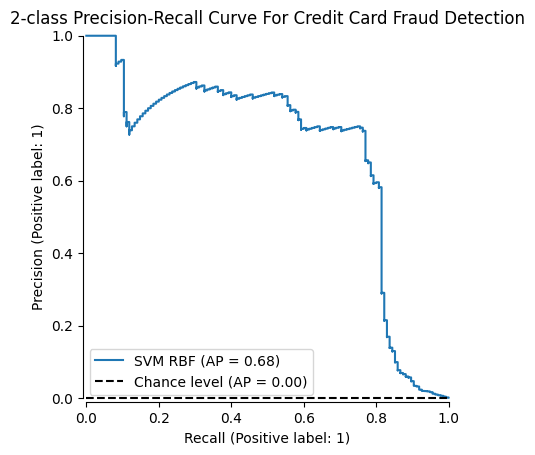

In [4]:
report = classification_report(y_test, test_preds, zero_division=0) #Getting Classification Report
print(report)

y_score = model.decision_function(X_test_scaled)

display = PrecisionRecallDisplay.from_predictions(
    y_test,
    y_score,
    name="SVM RBF",
    plot_chance_level=True,
    despine=True
)

_ = display.ax_.set_title("2-class Precision-Recall Curve For Credit Card Fraud Detection")

The classification report shows a very high accuracy, however due to the fact that only 0.17% of the dataset is fraud it doesn't mean too much. The recall for the fraud however is very good however the 0.09 precision when detecting fraud shows the model gets a lot of false positives when trying to detect fraudulent transactions which may be better from a banking perspective as each can be sent for human review in the end to verify whether or not a transaction is actually fraudulent.

The AUPRC shows an average precision (AP in the graph) of 0.68 in regards to how many fraudulent transactions the model finds.